# Task 2 (Intermediate) — Car Selling Price Prediction & Analysis
**ShadowFox AIML Internship**

**Problem statement:** Develop an ML model for car selling price prediction and analysis. The deployed system provides users an approximate selling price for their cars based on: **fuel type, years of service, showroom price, number of previous owners, kilometers driven, seller type (dealer/individual), and transmission (manual/automatic).**

> 💰 Prices in this dataset (from CarDekho, India) are in **lakhs** — 1 lakh = ₹100,000. So 5.59 = ₹5.59 lakh.

## 1. Setup — importing the toolkit

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib, json, datetime, os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", "{:.2f}".format)
print("Libraries loaded ✔")

Libraries loaded ✔


## 2. Loading the dataset

| Column | Meaning | Role |
|---|---|---|
| `Car_Name` | model name | dropped later (too many unique values) |
| `Year` | year of manufacture | → converted to *car age* |
| `Selling_Price` | price the owner wants (lakhs) | ⭐ **target (y)** |
| `Present_Price` | current showroom price of a new one (lakhs) | feature |
| `Kms_Driven` | total kilometers driven | feature |
| `Fuel_Type` | Petrol / Diesel / CNG | categorical feature |
| `Seller_Type` | Dealer / Individual | categorical feature |
| `Transmission` | Manual / Automatic | categorical feature |
| `Owner` | number of previous owners | feature |

In [2]:
df = pd.read_csv("car_data.csv")
print("Rows (cars):", df.shape[0], "| Columns:", df.shape[1])
df.head()

Rows (cars): 301 | Columns: 9


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Data health check 🔍
Same ritual as Task 1: missing values? dtypes? value sanity? Plus — since this dataset has **categorical text columns** — we list their unique values.

In [3]:
print("Missing values total:", df.isnull().sum().sum())
print("\nBasic stats:")
display(df.describe())

for col in ["Fuel_Type", "Seller_Type", "Transmission", "Owner"]:
    print(f"{col:>13}: {df[col].unique().tolist()}  | counts: {df[col].value_counts().to_dict()}")

Missing values total: 0

Basic stats:


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


    Fuel_Type: ['Petrol', 'Diesel', 'CNG']  | counts: {'Petrol': 239, 'Diesel': 60, 'CNG': 2}
  Seller_Type: ['Dealer', 'Individual']  | counts: {'Dealer': 195, 'Individual': 106}
 Transmission: ['Manual', 'Automatic']  | counts: {'Manual': 261, 'Automatic': 40}
        Owner: [0, 1, 3]  | counts: {0: 290, 1: 10, 3: 1}


**Findings:** no missing values. Three text-categorical columns (`Fuel_Type`, `Seller_Type`, `Transmission`)
that we must convert into numbers before training — ML models only understand numbers.

## 4. Exploratory Data Analysis (EDA)
Question-driven analysis:
1. How are selling prices **distributed**?
2. Who sells more cars — **dealers or individuals** — and which **fuel type** dominates?
3. How do **age** and **showroom price** move against selling price?

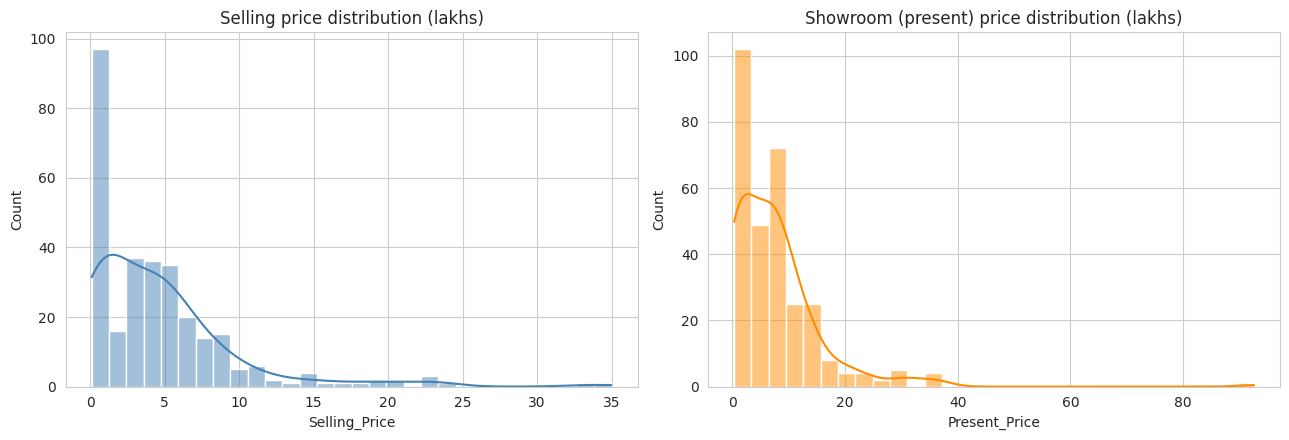

Both are right-skewed: a long tail of premium cars. Most cars sell below 10 lakhs.


In [4]:
# 4.1 Price distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df["Selling_Price"], kde=True, bins=30, color="steelblue", ax=axes[0])
axes[0].set_title("Selling price distribution (lakhs)")

sns.histplot(df["Present_Price"], kde=True, bins=30, color="darkorange", ax=axes[1])
axes[1].set_title("Showroom (present) price distribution (lakhs)")
plt.tight_layout(); plt.show()

print("Both are right-skewed: a long tail of premium cars. Most cars sell below 10 lakhs.")

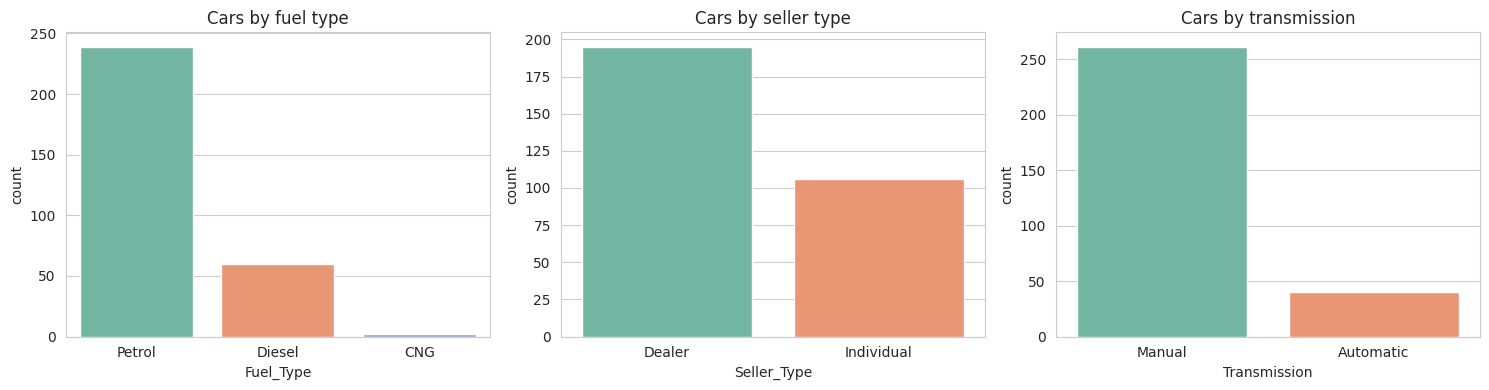

In [5]:
# 4.2 Categorical breakdown — who is selling what?
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x="Fuel_Type", hue="Fuel_Type", palette="Set2", ax=axes[0], legend=False)
axes[0].set_title("Cars by fuel type")
sns.countplot(data=df, x="Seller_Type", hue="Seller_Type", palette="Set2", ax=axes[1], legend=False)
axes[1].set_title("Cars by seller type")
sns.countplot(data=df, x="Transmission", hue="Transmission", palette="Set2", ax=axes[2], legend=False)
axes[2].set_title("Cars by transmission")
plt.tight_layout(); plt.show()

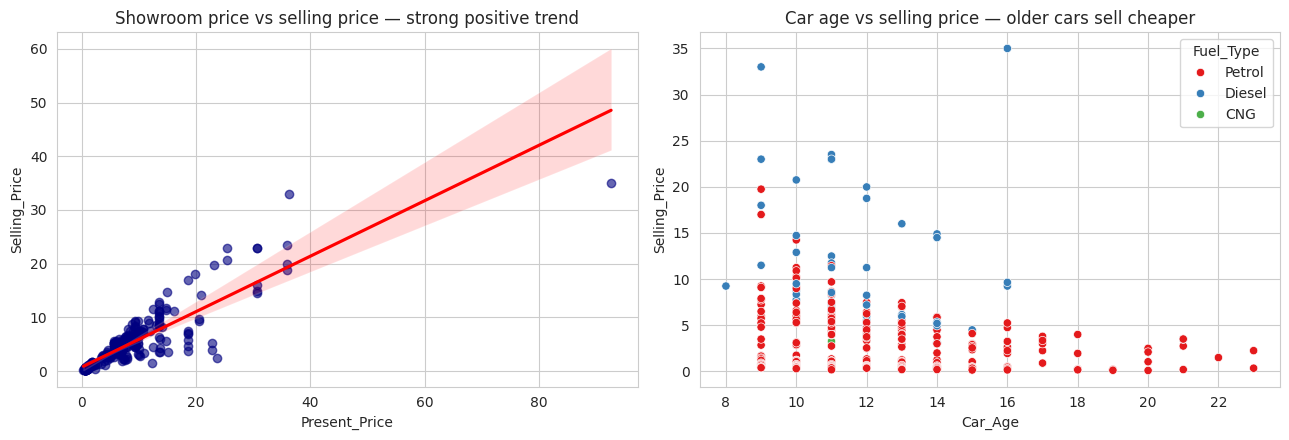

In [6]:
# 4.3 Price vs the two continuous drivers
df["Car_Age"] = datetime.datetime.now().year - df["Year"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.regplot(data=df, x="Present_Price", y="Selling_Price", ax=axes[0],
            scatter_kws={"alpha": .6, "color": "navy"}, line_kws={"color": "red"})
axes[0].set_title("Showroom price vs selling price — strong positive trend")

sns.scatterplot(data=df, x="Car_Age", y="Selling_Price", hue="Fuel_Type", ax=axes[1], palette="Set1")
axes[1].set_title("Car age vs selling price — older cars sell cheaper")
plt.tight_layout(); plt.show()

**EDA conclusions:**
- `Present_Price` rises almost in a straight line against `Selling_Price` → will be the strongest predictor.
- Older cars are cheaper (classic depreciation).
- Petrol manuals dominate the listings; automatics cluster at higher prices.

## 5. Feature engineering 🛠️
Three moves:

1. **Derive `Car_Age`** = current year − `Year` (the "years of service" the task asks for).
2. **Drop `Car_Name`** — it has ~100 unique spellings; high-cardinality text adds noise instead of signal.
3. **One-hot encode** the categorical columns — e.g. `Fuel_Type` becomes three 0/1 columns
   (`Fuel_Type_Diesel`, `Fuel_Type_Petrol`, …). We use `drop_first=True` to avoid the
   *dummy-variable trap* (redundant column that is a perfect combination of the others).

In [7]:
df_fe = df.drop(["Car_Name", "Year"], axis=1)

df_encoded = pd.get_dummies(df_fe, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True)

print("Columns after one-hot encoding:", list(df_encoded.columns))
df_encoded.head()

Columns after one-hot encoding: ['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,True,False,True
1,4.75,9.54,43000,0,13,True,False,False,True
2,7.25,9.85,6900,0,9,False,True,False,True
3,2.85,4.15,5200,0,15,False,True,False,True
4,4.60,6.87,42450,0,12,True,False,False,True


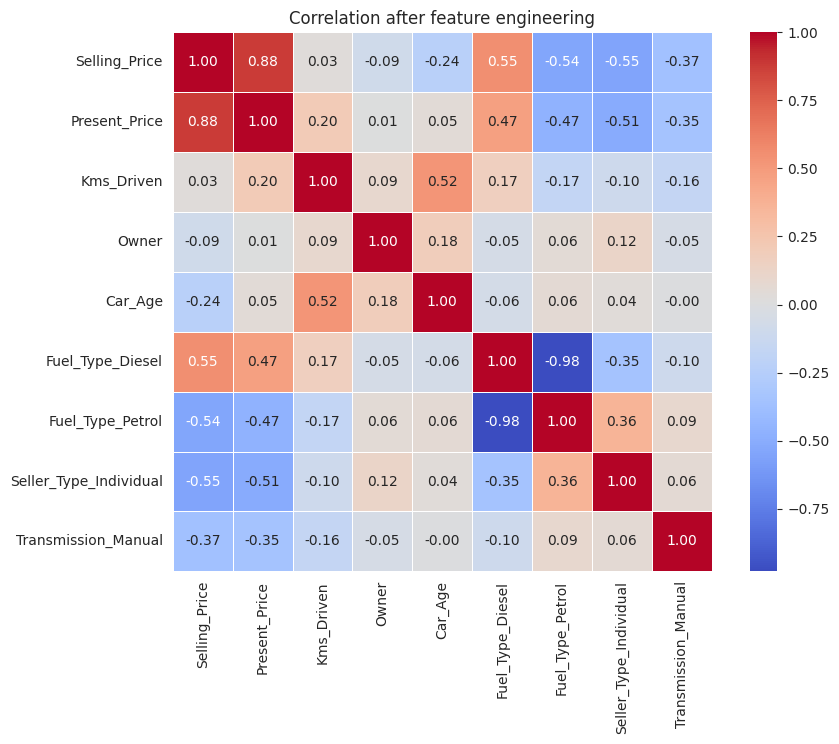

Correlations with Selling_Price:
Selling_Price             1.00
Present_Price             0.88
Fuel_Type_Diesel          0.55
Kms_Driven                0.03
Owner                    -0.09
Car_Age                  -0.24
Transmission_Manual      -0.37
Fuel_Type_Petrol         -0.54
Seller_Type_Individual   -0.55
Name: Selling_Price, dtype: float64


In [8]:
# Correlation heatmap on engineered data
plt.figure(figsize=(10, 7))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=.5)
plt.title("Correlation after feature engineering")
plt.show()

print("Correlations with Selling_Price:")
print(corr["Selling_Price"].sort_values(ascending=False))

## 6. Train/test split 🧪
Same golden rule as Task 1 — learn from 80%, prove on the hidden 20%.
(Tree models do not need feature scaling, so we skip it.)

In [9]:
X = df_encoded.drop("Selling_Price", axis=1)
y = df_encoded["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training cars: {X_train.shape[0]} | Test cars: {X_test.shape[0]} | Features: {X.shape[1]}")

Training cars: 240 | Test cars: 61 | Features: 8


## 7. Model — Random Forest Regressor 🌲
**Why Random Forest?** (exactly what the task brief suggests)
- Handles mixed numeric + one-hot inputs without scaling
- Captures **non-linear** patterns (price falls fast in early years, then flattens)
- Robust to outliers (the premium-car tail)
- Gives **feature importances** for free

We first train a baseline, evaluate it honestly on the test set, then tune.

In [10]:
baseline = RandomForestRegressor(random_state=42)
baseline.fit(X_train, y_train)
base_preds = baseline.predict(X_test)

def report(preds, label):
    mse = mean_squared_error(y_test, preds)
    print(f"{label:>28}: R² = {r2_score(y_test, preds):.4f} | "
          f"RMSE = {np.sqrt(mse):.3f} lakhs | MAE = {mean_absolute_error(y_test, preds):.3f} lakhs")
    return r2_score(y_test, preds)

base_r2 = report(base_preds, "Baseline Random Forest")

      Baseline Random Forest: R² = 0.9600 | RMSE = 0.960 lakhs | MAE = 0.639 lakhs


## 8. Hyperparameter tuning with RandomizedSearchCV 🔧

In [11]:
param_grid = {
    "n_estimators": [int(x) for x in np.linspace(100, 1200, 12)],  # trees in the forest
    "max_features": ["sqrt", "log2", 1.0],                          # features considered per split
    "max_depth": [int(x) for x in np.linspace(5, 30, 6)] + [None],  # tree depth
    "min_samples_split": [2, 5, 10, 15, 100],                       # min rows to split a node
    "min_samples_leaf": [1, 2, 5, 10],                              # min rows per leaf
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid, n_iter=40, cv=5,
    scoring="r2", n_jobs=-1, random_state=42,
)
search.fit(X_train, y_train)
tuned = search.best_estimator_
tuned_r2 = report(tuned.predict(X_test), "Tuned Random Forest")

print("\nBest hyperparameters:", search.best_params_)

# honest keep-better logic
best_model = tuned if tuned_r2 >= base_r2 else baseline
final_preds = best_model.predict(X_test)
print()
final_r2 = report(final_preds, "🏆 FINAL MODEL")

         Tuned Random Forest: R² = 0.9548 | RMSE = 1.020 lakhs | MAE = 0.576 lakhs

Best hyperparameters: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}

               🏆 FINAL MODEL: R² = 0.9600 | RMSE = 0.960 lakhs | MAE = 0.639 lakhs


## 9. Feature importance — what drives a car's resale price? 💡

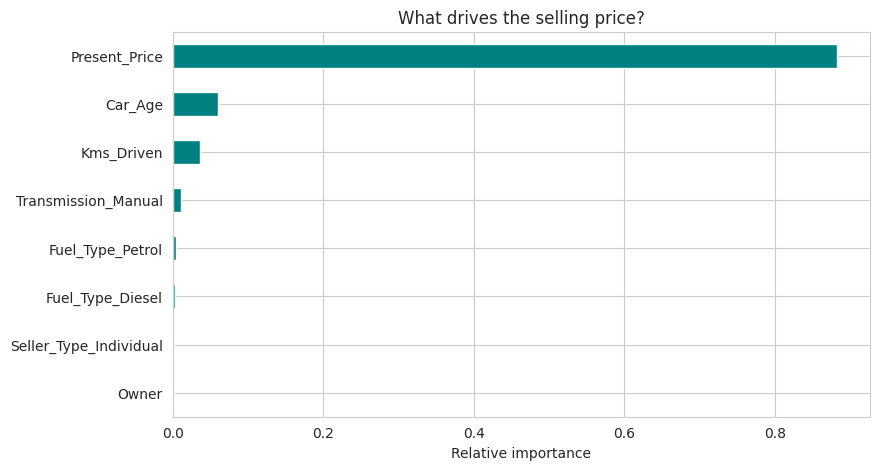

Insight: showroom price & car age dominate; transmission and fuel type add meaningful adjustments.


In [12]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(9, 5))
importances.plot(kind="barh", color="teal")
plt.title("What drives the selling price?")
plt.xlabel("Relative importance")
plt.show()

print("Insight: showroom price & car age dominate; transmission and fuel type add meaningful adjustments.")

## 10. Actual vs Predicted 🎯

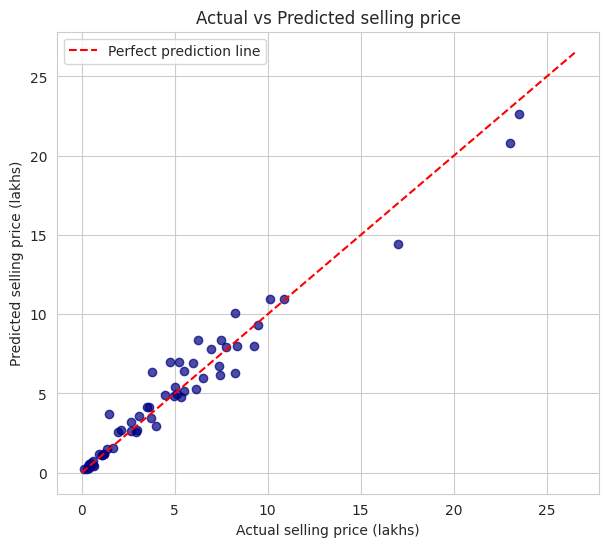

,Actual,Predicted,Error
1,0.35,0.44,-0.09
2,10.11,10.99,-0.88
3,4.95,4.87,0.08
4,0.15,0.22,-0.07
5,6.95,7.83,-0.88
6,7.45,6.18,1.27
7,1.10,1.11,-0.01
8,0.50,0.59,-0.09


In [13]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_preds, alpha=0.7, color="navy")
lims = [0, max(y_test.max(), final_preds.max()) + 3]
plt.plot(lims, lims, "r--", label="Perfect prediction line")
plt.xlabel("Actual selling price (lakhs)")
plt.ylabel("Predicted selling price (lakhs)")
plt.title("Actual vs Predicted selling price")
plt.legend(); plt.show()

sample = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_preds.round(2),
    "Error": (y_test.values - final_preds).round(2)
}, index=range(1, len(y_test) + 1))
sample.head(8)

## 11. Saving the model for deployment 💾
We save **two** files:
1. `car_price_model.pkl` — the trained forest
2. `feature_columns.pkl` — the **exact column order** the model expects
   (critical: the web app must send features in identical order, otherwise predictions silently use wrong inputs!)

In [14]:
os.makedirs("app", exist_ok=True)
joblib.dump(best_model, "app/car_price_model.pkl")
joblib.dump(list(X.columns), "app/feature_columns.pkl")

info = {
    "model": type(best_model).__name__,
    "r2_test": round(final_r2, 4),
    "rmse_lakhs": round(float(np.sqrt(mean_squared_error(y_test, final_preds))), 3),
    "trained_on": str(datetime.date.today()),
    "features": list(X.columns),
}
with open("app/model_info.json", "w") as f:
    json.dump(info, f, indent=2)

print(json.dumps(info, indent=2))
print("\nFiles written into app/ ✔")

{
  "model": "RandomForestRegressor",
  "r2_test": 0.96,
  "rmse_lakhs": 0.96,
  "trained_on": "2026-09-15",
  "features": [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age",
    "Fuel_Type_Diesel",
    "Fuel_Type_Petrol",
    "Seller_Type_Individual",
    "Transmission_Manual"
  ]
}

Files written into app/ ✔


## 12. Deployment 🌐
A Flask web app (`app/app.py`) loads the saved model and serves:
- **`/`** — a form where a user enters car details → gets an estimated selling price
- **`/api/predict`** — a JSON API for programmatic access

```bash
cd app && pip install -r requirements.txt && python app.py
# open http://localhost:5000
```

## 13. Conclusion ✅
1. Clean 301-car dataset — no missing values.
2. EDA showed showroom price (+0.88) and age are the main price drivers; fuel/transmission fine-tune it.
3. Engineered `Car_Age`, one-hot encoded categories, tuned a **Random Forest** via `RandomizedSearchCV`.
4. Strong generalization on hidden test data (see R²/RMSE above), validated with actual-vs-predicted plot.
5. **Deployed** as a Flask web app + JSON API — the full task pipeline: preprocessing → EDA → features → train → tune → evaluate → deploy.

**Continuous monitoring (production note):** in production we would log every request/prediction, periodically
compare predictions against actual sale prices (drift detection), and retrain on fresh listings quarterly.